<a href="https://colab.research.google.com/github/NinhHTK/ML-CPV-Documents/blob/main/SE196288.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
```
Course: DSR301m
Lab: 01 & 02
Name: Hà Thúc Khương Ninh
ID: SE196288
Class: AI2007
```
---
**Submission File**:
* Use **your StudentID** as file name (e.g., SE123456.ipynb)

* Only submit notebook file (.ipynb)

* Submit only once; if multiple submissions are made, the last file will be used, and points will be deducted.

**Deadline for submission: 22:00:00 PM on 02/10/2026**

**Late submission**: $-30\%$

**Link for submission**: https://forms.gle/19h7rBtGJtEEvd5B7



# Part 1 — R Programming Basics





1. (3pts) Create a simple "Keo, Bua, Bao" game in R. Enter data for 2 players. If the user wants to continue playing, press the Y button, otherwise press N. Use if, else if, and else statements to determine the winner based on the rules:
  
    -- Keo beats Bao

    -- Bao beats Bua

    -- Bua beats Keo

2. (2pts) Create an ATM program using repeat loop.

- Menu:

  -- Deposit money

  -- Withdraw money

  -- Check balance

  -- Exit

- Requirements:

  -- Initial balance = 1000

  -- Cannot withdraw more than current balance

  -- Cannot deposit negative values

  -- Use switch() statement


# Q1: "Keo, Bua, Bao" game


In [25]:
play_game <- function() {
  choices <- c("Keo", "Bua", "Bao") # Scissors, Rock, Paper

  repeat {
    # Prepare the prompt string with choices
    options_prompt <- paste0(
      "Choose your move:\n",
      "1. ", choices[1], "\n",
      "2. ", choices[2], "\n",
      "3. ", choices[3], "\n"
    )

    # Get player 1's choice, embedding options directly into the prompt
    player1_num_choice <- as.integer(readline(paste0(options_prompt, "Player 1, enter the number of your choice: ")))
    while (is.na(player1_num_choice) || !(player1_num_choice %in% 1:length(choices))) {
      player1_num_choice <- as.integer(readline("Invalid choice. Player 1, please enter a number from the list: "))
    }
    player1_choice <- tolower(choices[player1_num_choice])

    # Get player 2's choice (options already shown to player 1)
    player2_num_choice <- as.integer(readline("Player 2, enter the number of your choice: "))
    while (is.na(player2_num_choice) || !(player2_num_choice %in% 1:length(choices))) {
      player2_num_choice <- as.integer(readline("Invalid choice. Player 2, please enter a number from the list: "))
    }
    player2_choice <- tolower(choices[player2_num_choice])

    # Determine winner
    result <- ""
    if (player1_choice == player2_choice) {
      result <- "It's a draw!"
    } else if (
      (player1_choice == "keo" && player2_choice == "bao") || # Keo (Scissors) beats Bao (Paper)
      (player1_choice == "bao" && player2_choice == "bua") || # Bao (Paper) beats Bua (Rock)
      (player1_choice == "bua" && player2_choice == "keo")    # Bua (Rock) beats Keo (Scissors)
    ) {
      result <- "Player 1 wins!"
    } else {
      result <- "Player 2 wins!"
    }

    # In kết quả lập tức ra màn hình bằng cách xả bộ đệm (flush.console)
    cat("Player 1 chose: ", player1_choice, "\n", sep = "")
    cat("Player 2 chose: ", player2_choice, "\n", sep = "")
    cat(result, "\n", sep = "")
    flush.console()

    # Ask to play again
    play_again <- tolower(readline("Do you want to continue playing? (Y/N): "))
    if (play_again == "n") {
      cat("Thanks for playing!\n")
      flush.console()
      break
    } else if (play_again != "y") {
      cat("Invalid input. Assuming you want to continue.\n")
      flush.console()
    }
  }
}

# Call the function to start the game
play_game()

Choose your move:
1. Keo
2. Bua
3. Bao
Player 1, enter the number of your choice: 3
Player 2, enter the number of your choice: 2
Player 1 chose: bao
Player 2 chose: bua
Player 1 wins!
Do you want to continue playing? (Y/N): 1
Invalid input. Assuming you want to continue.
Choose your move:
1. Keo
2. Bua
3. Bao
Player 1, enter the number of your choice: 3
Player 2, enter the number of your choice: 3
Player 1 chose: bao
Player 2 chose: bao
It's a draw!
Do you want to continue playing? (Y/N): n
Thanks for playing!


# Q2: ATM program


In [26]:
# Cell 1: định nghĩa chương trình
atm_program <- function(inputs = NULL) {
  balance <- 1000
  queue <- inputs

  get_input <- function(prompt) {
    if (is.null(inputs)) return(readline(prompt))
    cat(prompt)
    val <- if (length(queue) == 0) "4" else queue[1]
    queue <<- queue[-1]
    cat(val, "\n")
    val
  }

  repeat {
    choice <- suppressWarnings(as.integer(get_input(paste0(
      "\nATM Menu:\n",
      "1. Deposit money\n",
      "2. Withdraw money\n",
      "3. Check balance\n",
      "4. Exit\n",
      "Enter your choice (1-4): "
    ))))

    if (length(choice) == 0 || is.na(choice) || !(choice %in% 1:4)) {
      cat("Invalid choice. Please enter a number between 1 and 4.\n")
      flush.console()
      next
    }

    if (choice == 1) {
      amount <- suppressWarnings(as.numeric(get_input("Enter amount to deposit: ")))
      if (length(amount) == 0 || is.na(amount) || amount <= 0) {
        cat("Invalid deposit amount. Please enter a positive number.\n")
      } else {
        balance <- balance + amount
        cat("Deposit successful! ", amount, " units deposited.\n", sep = "")
      }
      flush.console()
    } else if (choice == 2) {
      amount <- suppressWarnings(as.numeric(get_input("Enter amount to withdraw: ")))
      if (length(amount) == 0 || is.na(amount) || amount <= 0) {
        cat("Invalid withdrawal amount. Please enter a positive number.\n")
      } else if (amount > balance) {
        cat("Cannot withdraw more than current balance.\n")
      } else {
        balance <- balance - amount
        cat("Withdrawal successful! ", amount, " units withdrawn.\n", sep = "")
      }
      flush.console()
    } else if (choice == 3) {
      cat("Current balance: ", balance, " units.\n", sep = "")
      flush.console()
    } else {
      cat("Thank you for using the ATM. Goodbye!\n")
      flush.console()
      break
    }
  }
}

# Gọi hàm để chạy chương trình tương tác trực tiếp
atm_program()


ATM Menu:
1. Deposit money
2. Withdraw money
3. Check balance
4. Exit
Enter your choice (1-4): 1
Enter amount to deposit: 300
Deposit successful! 300 units deposited.

ATM Menu:
1. Deposit money
2. Withdraw money
3. Check balance
4. Exit
Enter your choice (1-4): 1400
Invalid choice. Please enter a number between 1 and 4.

ATM Menu:
1. Deposit money
2. Withdraw money
3. Check balance
4. Exit
Enter your choice (1-4): 2
Enter amount to withdraw: 1400
Cannot withdraw more than current balance.

ATM Menu:
1. Deposit money
2. Withdraw money
3. Check balance
4. Exit
Enter your choice (1-4): 3
Current balance: 1300 units.

ATM Menu:
1. Deposit money
2. Withdraw money
3. Check balance
4. Exit
Enter your choice (1-4): 4
Thank you for using the ATM. Goodbye!



# Part 2 — Database, EDA


In [27]:
# Cài thư viện (chỉ cài nếu chưa có)
pkgs <- c("DBI", "RSQLite", "ggplot2", "dplyr")
new  <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(new)) install.packages(new, repos = "https://cloud.r-project.org")

library(DBI)
library(RSQLite)
library(ggplot2)
library(dplyr)

# Kết nối SQLite và bật foreign key
con <- dbConnect(RSQLite::SQLite(), "mydatabase.db")
dbExecute(con, "PRAGMA foreign_keys = ON")
dbGetQuery(con, "SELECT sqlite_version()")

[1] 0

sqlite_version()
<chr>
3.53.3



1. (1pts) Create a database (SQLite) for an **E-commerce system** with 3 related tables: `Customers`, `Products`, `Orders`.
- `Orders` must reference `Customers` and `Products` via foreign keys.
- Includes missing data (NULL values) to simulate real-world scenarios (e.g. a customer with no phone number, an order with no discount applied). Data columns must have at least one NULL value.


In [28]:
invisible(lapply(c("Orders", "Products", "Customers"),
                 function(t) dbExecute(con, paste("DROP TABLE IF EXISTS", t))))

invisible(dbExecute(con, "CREATE TABLE Customers (
  customer_id INTEGER PRIMARY KEY, name TEXT NOT NULL, email TEXT,
  phone TEXT, city TEXT, signup_date TEXT)"))
invisible(dbExecute(con, "CREATE TABLE Products (
  product_id INTEGER PRIMARY KEY, product_name TEXT NOT NULL,
  category TEXT, price REAL, stock INTEGER)"))
invisible(dbExecute(con, "CREATE TABLE Orders (
  order_id INTEGER PRIMARY KEY, customer_id INTEGER NOT NULL, product_id INTEGER NOT NULL,
  quantity INTEGER, discount REAL, order_date TEXT, status TEXT,
  FOREIGN KEY (customer_id) REFERENCES Customers(customer_id),
  FOREIGN KEY (product_id) REFERENCES Products(product_id))"))

# Sinh dữ liệu
set.seed(42)
n_c <- 30; n_p <- 12; n_o <- 120

customers <- data.frame(
  customer_id = 1:n_c,
  name = paste("Customer", 1:n_c),
  email = paste0("user", 1:n_c, "@mail.com"),
  phone = paste0("09", sample(10000000:99999999, n_c)),
  city = sample(c("HCMC", "Hanoi", "Da Nang", "Can Tho"), n_c, replace = TRUE),
  signup_date = as.character(sample(seq(as.Date("2023-01-01"), as.Date("2024-12-31"), by = "day"), n_c)))
customers$phone[sample(n_c, 6)] <- NA
customers$email[sample(n_c, 3)] <- NA
customers$city[sample(n_c, 4)] <- NA
customers$signup_date[sample(n_c, 2)] <- NA

products <- data.frame(
  product_id = 1:n_p,
  product_name = paste("Product", LETTERS[1:n_p]),
  category = rep(c("Electronics", "Fashion", "Home", "Books"), each = 3),
  price = round(runif(n_p, 5, 500), 2),
  stock = sample(0:200, n_p))
products$stock[sample(n_p, 2)] <- NA
products$category[sample(n_p, 1)] <- NA
products$price[sample(n_p, 1)] <- NA

orders <- data.frame(
  order_id = 1:n_o,
  customer_id = sample(1:n_c, n_o, replace = TRUE),
  product_id = sample(1:n_p, n_o, replace = TRUE),
  quantity = sample(1:5, n_o, replace = TRUE),
  discount = sample(c(0.05, 0.1, 0.15, 0.2), n_o, replace = TRUE),
  order_date = as.character(sample(seq(as.Date("2024-01-01"), as.Date("2024-12-31"), by = "day"), n_o, replace = TRUE)),
  status = sample(c("Completed", "Shipped", "Cancelled"), n_o, replace = TRUE, prob = c(.6, .3, .1)))
orders$discount[sample(n_o, 40)] <- NA
orders$status[sample(n_o, 5)] <- NA
orders$quantity[sample(n_o, 3)] <- NA
orders$order_date[sample(n_o, 3)] <- NA

invisible(dbAppendTable(con, "Customers", customers))
invisible(dbAppendTable(con, "Products", products))
invisible(dbAppendTable(con, "Orders", orders))

# ===== Hiển thị kết quả Q1 =====
cat("===== Q1: DATABASE ĐÃ TẠO =====\n")
cat("Các bảng:", paste(dbListTables(con), collapse = ", "), "\n\n")

cat("--- Cấu trúc bảng ---\n")
for (t in c("Customers", "Products", "Orders")) {
  cat("\n[", t, "]\n", sep = "")
  print(dbGetQuery(con, sprintf("PRAGMA table_info(%s)", t))[, c("name", "type", "notnull", "pk")])
}

cat("\n--- Khóa ngoại của Orders ---\n")
print(dbGetQuery(con, "PRAGMA foreign_key_list(Orders)")[, c("from", "table", "to")])

cat("\n--- Kiểm tra FK (rỗng = hợp lệ) ---\n")
print(dbGetQuery(con, "PRAGMA foreign_key_check"))

cat("\n--- Số dòng mỗi bảng ---\n")
for (t in c("Customers", "Products", "Orders"))
  cat(t, ":", dbGetQuery(con, paste("SELECT COUNT(*) FROM", t))[[1]], "dòng\n")

cat("\n--- Số NULL theo cột ---\n")
for (t in c("Customers", "Products", "Orders")) {
  d <- dbReadTable(con, t)
  cat("\n[", t, "]\n", sep = "")
  print(colSums(is.na(d))[colSums(is.na(d)) > 0])
}

cat("\n--- Ví dụ dòng có NULL ---\n")
print(dbGetQuery(con, "SELECT customer_id, name, phone, email, city, signup_date FROM Customers
                       WHERE phone IS NULL OR email IS NULL OR city IS NULL OR signup_date IS NULL LIMIT 5"))
print(dbGetQuery(con, "SELECT order_id, customer_id, product_id, quantity, discount, order_date, status FROM Orders
                       WHERE discount IS NULL OR status IS NULL OR quantity IS NULL OR order_date IS NULL LIMIT 5"))

===== Q1: DATABASE ĐÃ TẠO =====
Các bảng: Customers, Orders, Products 

--- Cấu trúc bảng ---

[Customers]
         name    type notnull pk
1 customer_id INTEGER       0  1
2        name    TEXT       1  0
3       email    TEXT       0  0
4       phone    TEXT       0  0
5        city    TEXT       0  0
6 signup_date    TEXT       0  0

[Products]
          name    type notnull pk
1   product_id INTEGER       0  1
2 product_name    TEXT       1  0
3     category    TEXT       0  0
4        price    REAL       0  0
5        stock INTEGER       0  0

[Orders]
         name    type notnull pk
1    order_id INTEGER       0  1
2 customer_id INTEGER       1  0
3  product_id INTEGER       1  0
4    quantity INTEGER       0  0
5    discount    REAL       0  0
6  order_date    TEXT       0  0
7      status    TEXT       0  0

--- Khóa ngoại của Orders ---
         from     table          to
1  product_id  Products  product_id
2 customer_id Customers customer_id

--- Kiểm tra FK (rỗng = hợp lệ) 


2.  (2pts) Exploratory Data Analysis (EDA) of Q1.
* Preview the data.
* Summary statistics.
* Missing data check and update database.


In [29]:
cust <- dbReadTable(con, "Customers")
prod <- dbReadTable(con, "Products")
ord  <- dbReadTable(con, "Orders")

# Preview
cat("===== PREVIEW =====\n")
print(head(cust)); print(head(prod)); print(head(ord))

# Summary statistics
cat("\n===== SUMMARY =====\n")
print(summary(cust)); print(summary(prod)); print(summary(ord))

# Missing trước xử lý (chỉ hiện cột có NULL)
miss <- function(d) { m <- colSums(is.na(d)); m[m > 0] }
cat("\n===== MISSING TRƯỚC XỬ LÝ =====\n")
cat("\n[Customers]\n"); print(miss(cust))
cat("\n[Products]\n");  print(miss(prod))
cat("\n[Orders]\n");    print(miss(ord))

# Xử lý missing + cập nhật database
upd <- function(sql) invisible(dbExecute(con, sql))
med_stock <- median(prod$stock, na.rm = TRUE)
med_price <- median(prod$price, na.rm = TRUE)
med_qty   <- median(ord$quantity, na.rm = TRUE)

upd("UPDATE Customers SET phone = 'Unknown' WHERE phone IS NULL")
upd("UPDATE Customers SET email = 'Unknown' WHERE email IS NULL")
upd("UPDATE Customers SET city = 'Unknown' WHERE city IS NULL")
upd("UPDATE Customers SET signup_date = 'Unknown' WHERE signup_date IS NULL")
upd("UPDATE Products SET category = 'Other' WHERE category IS NULL")
upd(sprintf("UPDATE Products SET stock = %s WHERE stock IS NULL", med_stock))
upd(sprintf("UPDATE Products SET price = %s WHERE price IS NULL", med_price))
upd("UPDATE Orders SET discount = 0 WHERE discount IS NULL")
upd("UPDATE Orders SET status = 'Unknown' WHERE status IS NULL")
upd(sprintf("UPDATE Orders SET quantity = %s WHERE quantity IS NULL", med_qty))
upd("UPDATE Orders SET order_date = '2024-06-15' WHERE order_date IS NULL")

# Missing sau xử lý
cat("\n===== MISSING SAU XỬ LÝ =====\n")
for (t in c("Customers", "Products", "Orders")) {
  n <- sum(is.na(dbReadTable(con, t)))
  cat(sprintf("%-10s: %d NULL còn lại\n", t, n))
}

===== PREVIEW =====
  customer_id       name          email      phone    city signup_date
1           1 Customer 1 user1@mail.com 0946761572    HCMC  2023-12-26
2           2 Customer 2 user2@mail.com 0931025944    HCMC  2023-10-23
3           3 Customer 3 user3@mail.com 0981927011    HCMC  2023-05-29
4           4 Customer 4 user4@mail.com 0986620409 Da Nang  2024-07-22
5           5 Customer 5 user5@mail.com 0913191935    <NA>  2023-04-10
6           6 Customer 6           <NA> 0996947863    HCMC  2023-10-25
  product_id product_name    category  price stock
1          1    Product A Electronics 216.61    14
2          2    Product B Electronics  72.56    NA
3          3    Product C Electronics 413.22   169
4          4    Product D     Fashion 298.19   187
5          5    Product E     Fashion 398.23    11
6          6    Product F     Fashion 385.67   127
  order_id customer_id product_id quantity discount order_date    status
1        1          29          4        1     0.10 2


3. (2pts) Use JOIN operator for tables after handling missing data. Visualize for that data (at least 5 charts) and discuss for each chart.


  order_id quantity discount order_date    status customer_name    city
1        1        1     0.10 2024-06-04   Shipped   Customer 29    HCMC
2        2        4     0.05 2024-12-31 Completed   Customer 30   Hanoi
3        3        3     0.20 2024-04-06 Completed   Customer 14 Da Nang
4        4        4     0.10 2024-07-02   Unknown    Customer 2    HCMC
5        5        3     0.15 2024-06-15   Shipped   Customer 28   Hanoi
6        6        4     0.20 2024-12-06 Completed    Customer 2    HCMC
  product_name    category  price  revenue month
1    Product D     Fashion 298.19  268.371    06
2    Product D     Fashion 298.19 1133.122    12
3    Product G        Home 459.44 1102.656    04
4    Product A Electronics 216.61  779.796    07
5    Product K       Books 374.94  956.097    06
6    Product E     Fashion 398.23 1274.336    12
Chart 1: 'Fashion' có doanh thu cao nhất (28424), là nhóm đóng góp chính; thấp nhất là 'Other'.



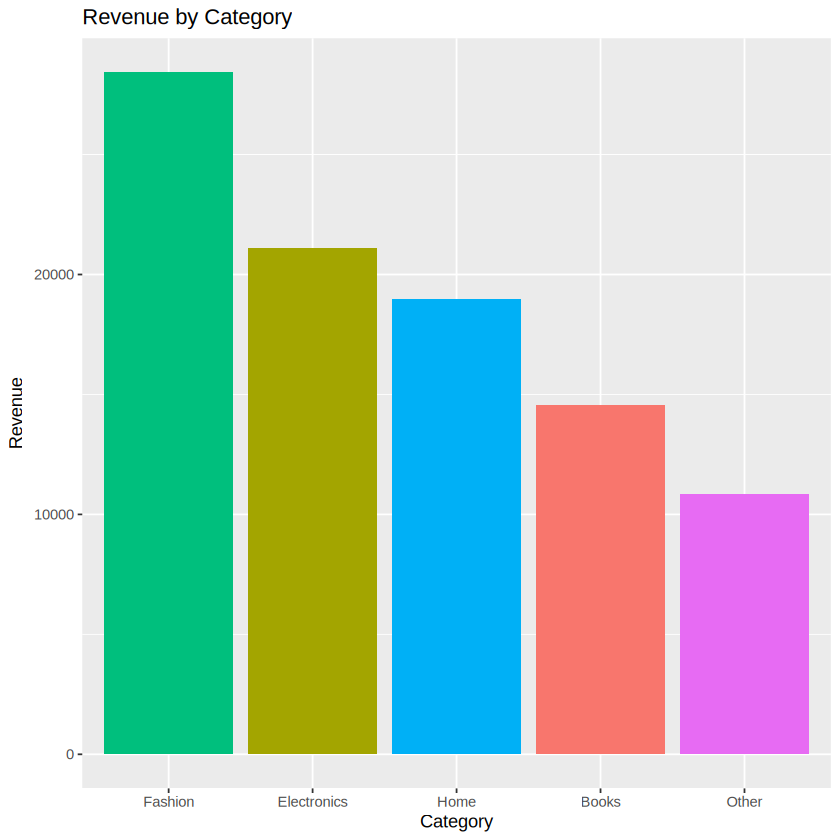

Chart 2: Top 10 khách hàng chiếm 56.1 % tổng doanh thu, nên ưu tiên chăm sóc nhóm này.



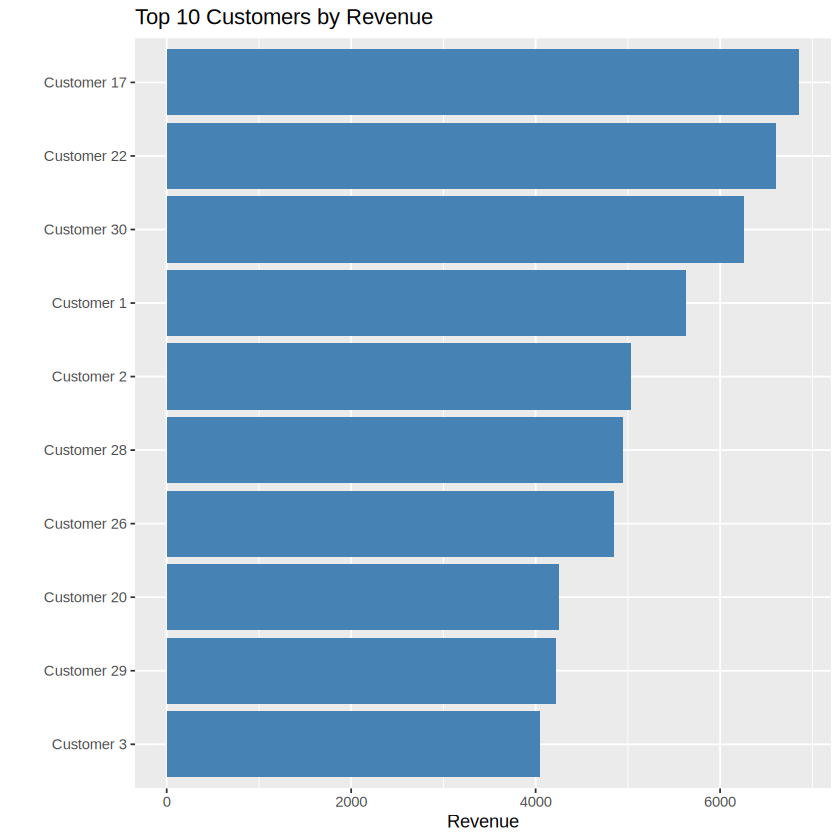

Chart 3: Doanh thu cao nhất ở tháng 06 và thấp nhất ở tháng 11 ; biến động cho thấy có tính thời vụ.



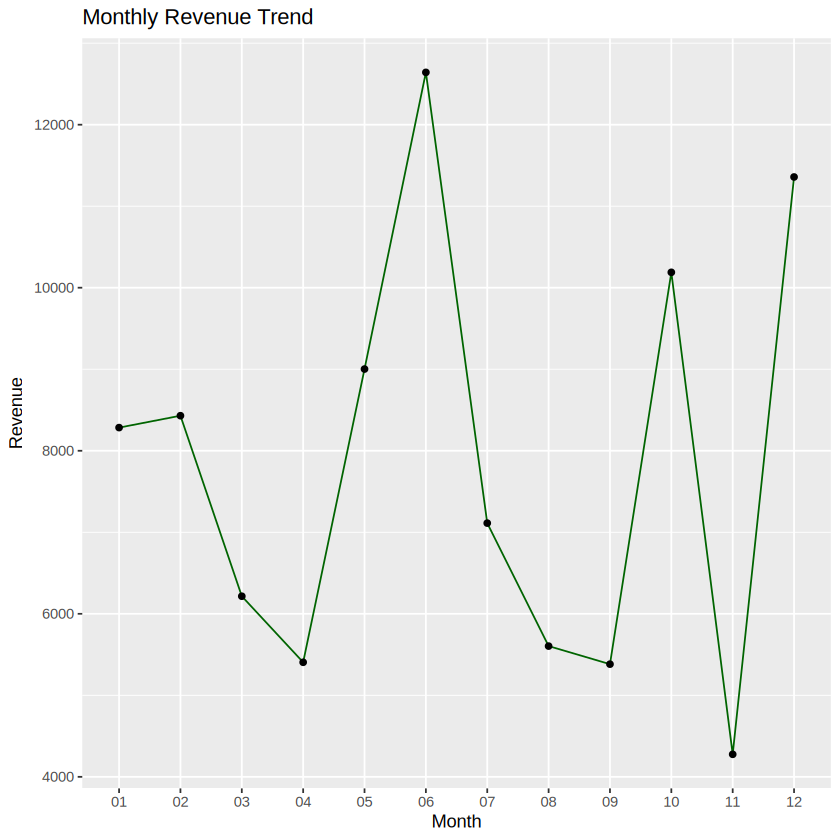

Chart 4: Đơn không giảm giá (0) chiếm 33.3 % (chủ yếu là NULL đã điền 0); các mức giảm còn lại phân bố khá đều.



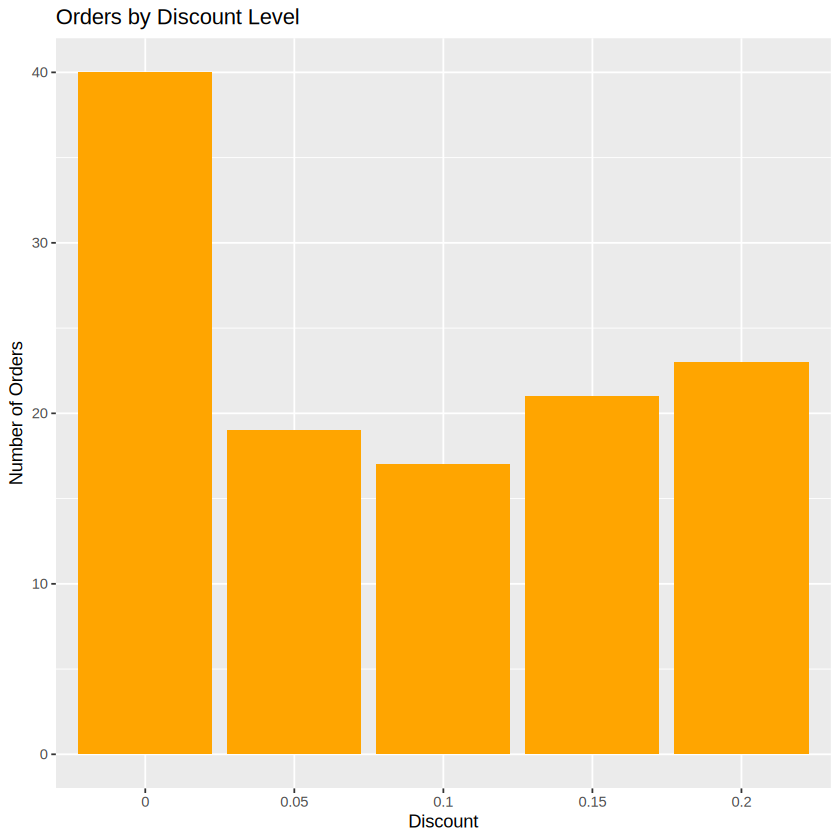

Chart 5: Median doanh thu mỗi đơn giữa các thành phố gần tương đương; outlier là các đơn số lượng lớn hoặc sản phẩm giá cao. 'Unknown' là khách thiếu city.



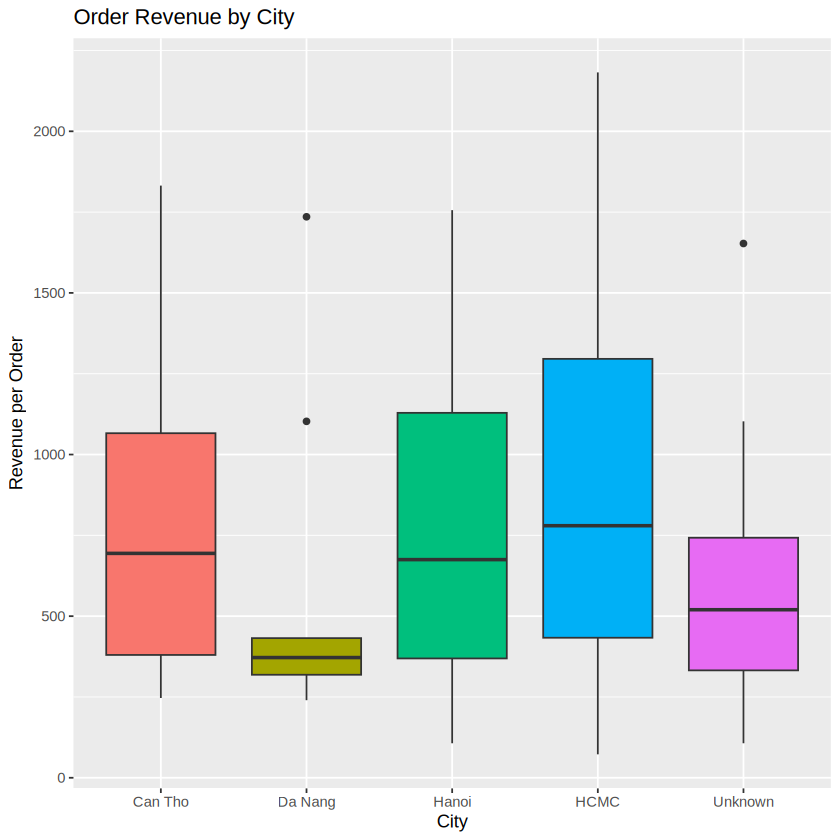

Chart 6: Completed chiếm 62.5 %, Cancelled thấp nên tỷ lệ hủy đơn ở mức chấp nhận được.


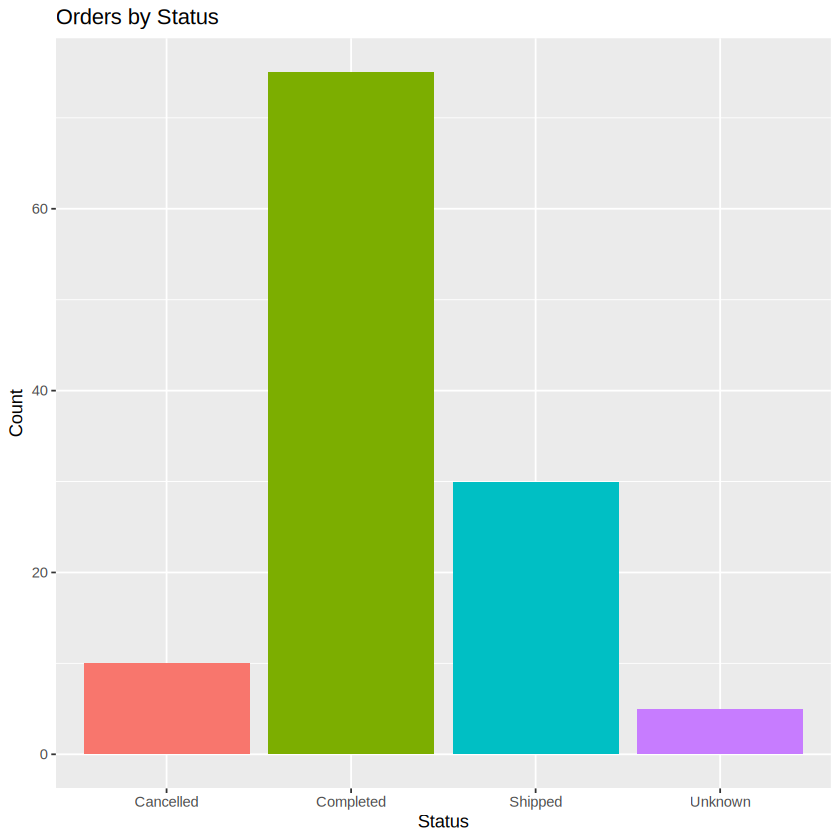

In [30]:
df <- dbGetQuery(con, "
  SELECT o.order_id, o.quantity, o.discount, o.order_date, o.status,
         c.name AS customer_name, c.city,
         p.product_name, p.category, p.price,
         o.quantity * p.price * (1 - o.discount) AS revenue
  FROM Orders o
  JOIN Customers c ON o.customer_id = c.customer_id
  JOIN Products  p ON o.product_id  = p.product_id")
df$month <- format(as.Date(df$order_date), "%m")
print(head(df))

# Chart 1: Doanh thu theo category
d <- df %>% group_by(category) %>% summarise(revenue = sum(revenue))
print(ggplot(d, aes(reorder(category, -revenue), revenue, fill = category)) +
  geom_col(show.legend = FALSE) + labs(title = "Revenue by Category", x = "Category", y = "Revenue"))
cat("Chart 1: '", d$category[which.max(d$revenue)], "' có doanh thu cao nhất (", round(max(d$revenue)),
    "), là nhóm đóng góp chính; thấp nhất là '", d$category[which.min(d$revenue)], "'.\n\n", sep = "")

# Chart 2: Top 10 khách hàng
d <- df %>% group_by(customer_name) %>% summarise(revenue = sum(revenue)) %>% slice_max(revenue, n = 10)
print(ggplot(d, aes(reorder(customer_name, revenue), revenue)) +
  geom_col(fill = "steelblue") + coord_flip() + labs(title = "Top 10 Customers by Revenue", x = "", y = "Revenue"))
cat("Chart 2: Top 10 khách hàng chiếm", round(sum(d$revenue) / sum(df$revenue) * 100, 1),
    "% tổng doanh thu, nên ưu tiên chăm sóc nhóm này.\n\n")

# Chart 3: Doanh thu theo tháng
d <- df %>% group_by(month) %>% summarise(revenue = sum(revenue))
print(ggplot(d, aes(month, revenue, group = 1)) + geom_line(color = "darkgreen") + geom_point() +
  labs(title = "Monthly Revenue Trend", x = "Month", y = "Revenue"))
cat("Chart 3: Doanh thu cao nhất ở tháng", d$month[which.max(d$revenue)], "và thấp nhất ở tháng",
    d$month[which.min(d$revenue)], "; biến động cho thấy có tính thời vụ.\n\n")

# Chart 4: Phân bố discount
print(ggplot(df, aes(factor(discount))) + geom_bar(fill = "orange") +
  labs(title = "Orders by Discount Level", x = "Discount", y = "Number of Orders"))
cat("Chart 4: Đơn không giảm giá (0) chiếm", round(mean(df$discount == 0) * 100, 1),
    "% (chủ yếu là NULL đã điền 0); các mức giảm còn lại phân bố khá đều.\n\n")

# Chart 5: Doanh thu mỗi đơn theo thành phố
print(ggplot(df, aes(city, revenue, fill = city)) + geom_boxplot(show.legend = FALSE) +
  labs(title = "Order Revenue by City", x = "City", y = "Revenue per Order"))
cat("Chart 5: Median doanh thu mỗi đơn giữa các thành phố gần tương đương; outlier là các đơn số lượng lớn hoặc sản phẩm giá cao. 'Unknown' là khách thiếu city.\n\n")

# Chart 6: Trạng thái đơn hàng
d <- df %>% count(status)
print(ggplot(d, aes(status, n, fill = status)) + geom_col(show.legend = FALSE) +
  labs(title = "Orders by Status", x = "Status", y = "Count"))
cat("Chart 6: Completed chiếm", round(d$n[d$status == "Completed"] / sum(d$n) * 100, 1),
    "%, Cancelled thấp nên tỷ lệ hủy đơn ở mức chấp nhận được.\n")

dbDisconnect(con)
